<u><b><h1 style="text-align:center; line-height:25px; color:#000000; background:#EFEFEF; border: 1px solid #FF6B6B ; padding:20px;">Extracting Prevalent Topics from Citizens Complaints using NLP</h1></b></u>
<u><h2 style="text-align:center">4. Topic Modeling</h2></u>
**Course:** DLBDSEDA02 – Project: Data Analysis  
**Tools**: Python, pandas, NLTK, scikit-learn, gensim, Matplotlib  
**Dataset:** <a href="https://www.kaggle.com/datasets/xjoury/customer-complaints-sentiment-and-priority-dataset">Customer Complaints Sentiment and Priority Dataset</a>  
**<a href="https://github.com/davidlupau/complaint-topic-modeling">GitHub repository</a>**

<b><h2 style="padding: 10px; border-left: 3px solid #FF6B6B;">Setup & Imports</h2></b>

In [2]:
import sys
from pathlib import Path

import joblib
import pandas as pd
from scipy.sparse import load_npz

PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "src").is_dir()
)
sys.path.append(str(PROJECT_ROOT / "src"))

from topic_modeling import (
    evaluate_lsa_k,
    evaluate_lda_k,
    plot_k_selection,
    fit_lsa,
    fit_lda,
    get_top_words,
    plot_top_words,
    compare_topic_overlap,
    assign_dominant_topic,
    plot_topic_vs_product,
)

print("Import successful")

Import successful


### Loading clean dataset

In [3]:
df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "complaints_clean.csv")
print(f"Loaded {df.shape[0]} cleaned complaints")

Loaded 1745 cleaned complaints


---

### Loading vectorized artifacts

`03_vectorization.ipynb` already fit and saved both pipelines to `data/vectorized/`, so they're loaded here directly (via `joblib`/`scipy.sparse`) rather than refit from scratch.

In [4]:
VECTOR_DIR = PROJECT_ROOT / "data" / "vectorized"

tfidf_vectorizer = joblib.load(VECTOR_DIR / "tfidf_vectorizer.joblib")
tfidf_matrix = load_npz(VECTOR_DIR / "tfidf_matrix.npz")
count_vectorizer = joblib.load(VECTOR_DIR / "count_vectorizer.joblib")
count_matrix = load_npz(VECTOR_DIR / "count_matrix.npz")

print(f"Loaded TF-IDF matrix: {tfidf_matrix.shape}")
print(f"Loaded count matrix: {count_matrix.shape}")

Loaded TF-IDF matrix: (1745, 2600)
Loaded count matrix: (1745, 2600)


---

<b><h2 style="padding: 10px; border-left: 3px solid #FF6B6B;">Selecting k — LSA (explained variance)</h2></b>

LSA has no single automatic stopping rule: total explained variance increases monotonically with more components, so there's no interior maximum to detect. Instead, scanning explained variance across a range of k (3–10) lets us look for the point where each extra component starts adding only marginal variance — the "elbow" beyond which adding topics buys little additional structure.


Evaluating LSA explained variance across k...

k=3: explained variance = 0.0367
k=4: explained variance = 0.0474
k=5: explained variance = 0.0560
k=6: explained variance = 0.0642
k=7: explained variance = 0.0717
k=8: explained variance = 0.0788
k=9: explained variance = 0.0853
k=10: explained variance = 0.0919
Saved plot to: /Users/davidlupau/Documents/Filen/_IU/6th semester/32. Project Data Analysis/complaint-topic-modeling/analysis_output/lsa_explained_variance_by_k.png


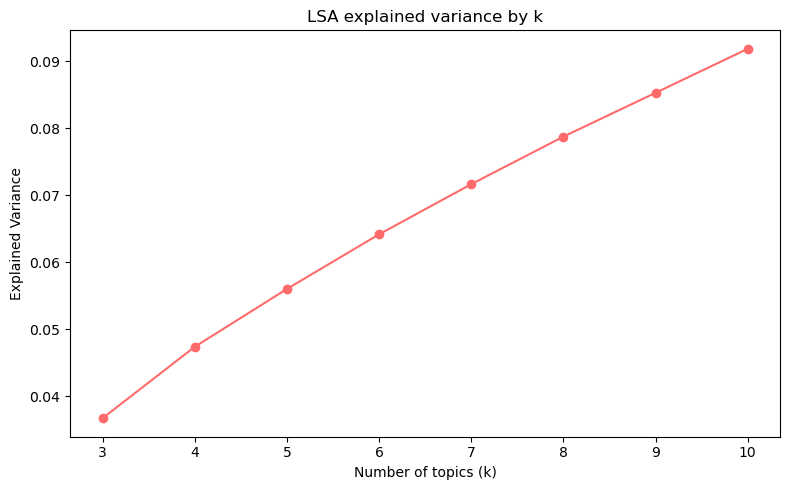

In [5]:
lsa_k_results = evaluate_lsa_k(tfidf_matrix)
plot_k_selection(lsa_k_results, "explained_variance", "LSA explained variance by k")

The curve rises roughly linearly across k=3–10 with no visible elbow. Each additional component adds a similar, slowly-diminishing amount of variance rather than showing a clear point of diminishing returns. In absolute terms, even at k=10 only 9.2% of total variance is explained, reflecting how thinly distributed the signal is across a 2,600-term sparse vocabulary. Because this curve alone doesn't point to a specific k, the final k for LSA was taken from LDA's coherence criterion instead (see below), to keep both pipelines directly comparable.

---

<b><h2 style="padding: 10px; border-left: 3px solid #FF6B6B;">Selecting k — LDA (u_mass coherence)</h2></b>

Unlike LSA's explained variance, LDA's u_mass coherence is not monotonic in k — it rewards topics whose top words genuinely co-occur in the same documents, and penalizes topics that fragment into less coherent, more diffuse word groups as k grows too large. This gives it an interior peak (values closer to 0 are better, since u_mass is always negative), making it a standard data-driven criterion for picking k in LDA specifically. The same k_range (3–10) is used here as for LSA so both pipelines stay comparable.


Evaluating LDA u_mass coherence across k...

k=3: u_mass coherence = -1.2373
k=4: u_mass coherence = -1.3100
k=5: u_mass coherence = -1.2669
k=6: u_mass coherence = -1.2010
k=7: u_mass coherence = -1.3192
k=8: u_mass coherence = -1.2563
k=9: u_mass coherence = -1.4476
k=10: u_mass coherence = -1.7022
Saved plot to: /Users/davidlupau/Documents/Filen/_IU/6th semester/32. Project Data Analysis/complaint-topic-modeling/analysis_output/lda_u_mass_coherence_by_k.png


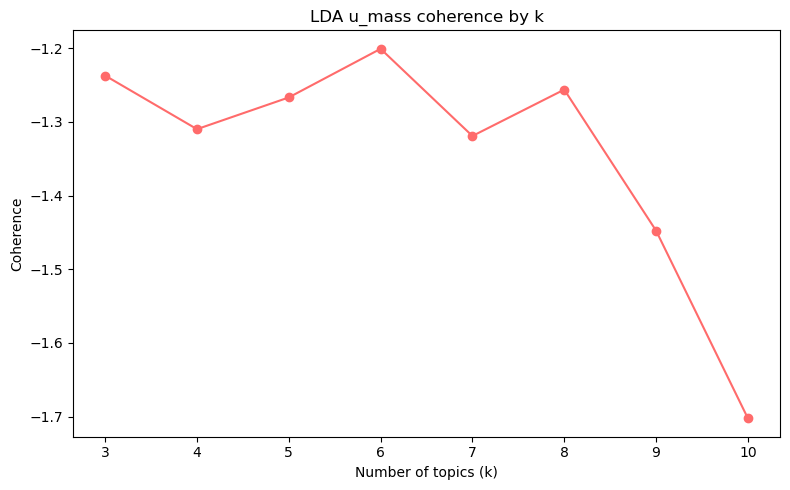

In [6]:
lda_k_results = evaluate_lda_k(count_matrix, count_vectorizer)
plot_k_selection(lda_k_results, "coherence", "LDA u_mass coherence by k")

Coherence peaks at k=6 (-1.20), is comparatively flat and noisy across k=3–8, then drops sharply at k=9 and k=10 as topics become less internally consistent. k=6 was therefore chosen as CHOSEN_K for both pipelines. The relatively shallow peak (k=3–8 all sit within a similar range) suggests this choice shouldn't be treated as a rigid optimum — k=5 or k=7 would likely produce comparably interpretable topics — but k=6 is a defensible, criterion-based pick rather than an arbitrary one.

---

<b><h2 style="padding: 10px; border-left: 3px solid #FF6B6B;">Fitting final LSA and LDA models</h2></b>

Having scanned k across both criteria above, we now fix a single k and fit the final models to actually inspect their topics. `CHOSEN_K` defaults to the k with the highest (least negative) LDA coherence — the same automatic rule `run_topic_modeling()` uses for headless runs (e.g. via `main.py`) — so this notebook stays runnable end-to-end without manual input. After reading the two interpretation cells above, override `CHOSEN_K` here if the plots suggest a different k is more defensible.

Chosen k: 6
Fitted LSA with 6 components (explained variance: 0.0642)
Fitted LDA with 6 components
Topic 0: payment, credit, loan, bank, card, report, would, time, money, told
Topic 1: credit, report, debt, reporting, information, collection, bureau, inquiry, equifax, agency
Topic 2: loan, payment, mortgage, interest, late, navient, student, monthly, month, rate
Topic 3: card, payment, credit, late, fee, charge, balance, chase, statement, charged
Topic 4: loan, fargo, mortgage, bank, well, credit, inquiry, report, home, rate
Topic 5: card, debt, charge, chase, loan, fee, collection, interest, rate, service
Topic 0: told, would, money, check, called, said, bank, back, call, well
Topic 1: call, coinbase, phone, number, email, company, received, bank, money, day
Topic 2: bank, transaction, fee, paypal, money, would, customer, deposit, service, day
Topic 3: credit, report, debt, information, letter, reporting, collection, dispute, agency, bureau
Topic 4: card, credit, charge, bank, balance

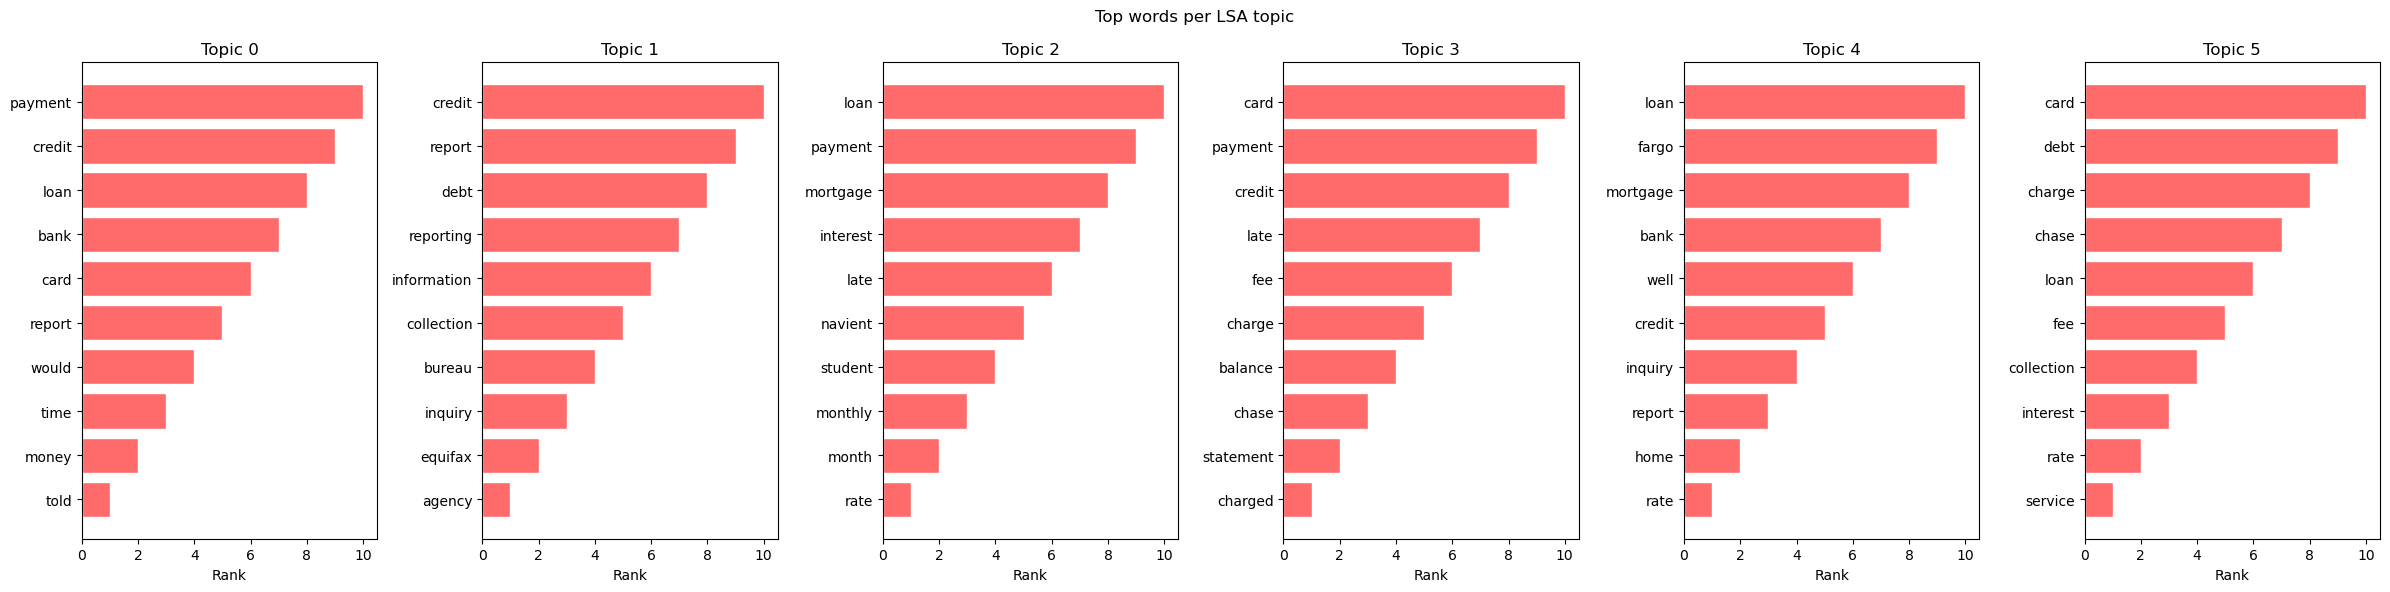

Saved plot to: /Users/davidlupau/Documents/Filen/_IU/6th semester/32. Project Data Analysis/complaint-topic-modeling/analysis_output/top_words_per_lda_topic.png


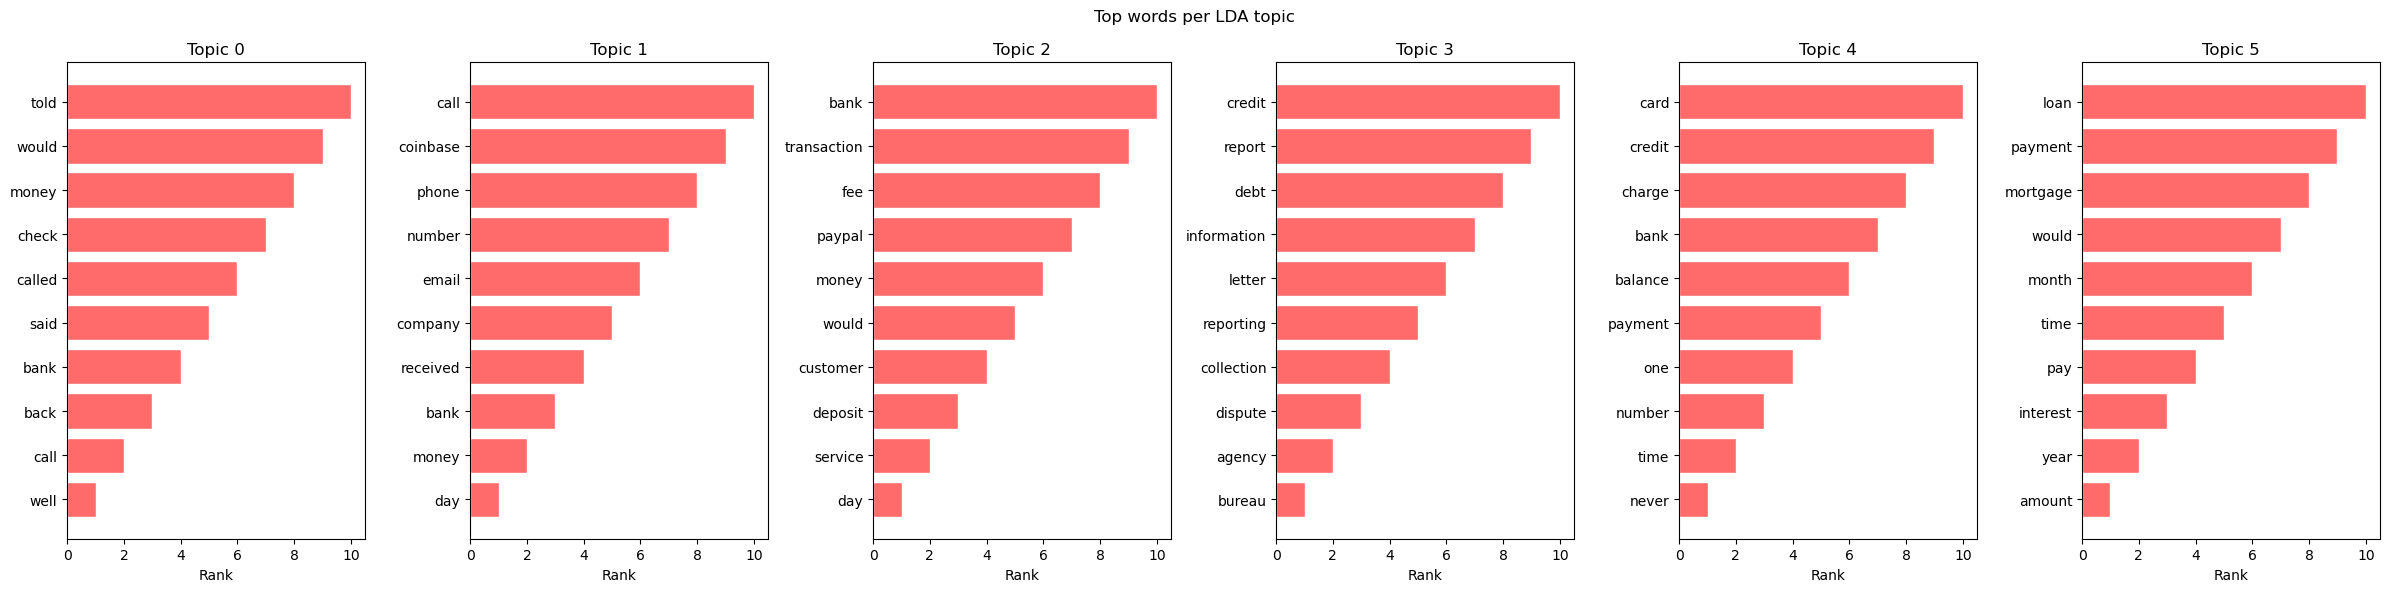

In [7]:
CHOSEN_K = int(lda_k_results.loc[lda_k_results["coherence"].idxmax(), "k"])
print(f"Chosen k: {CHOSEN_K}")

lsa_model = fit_lsa(tfidf_matrix, CHOSEN_K)
lda_model = fit_lda(count_matrix, CHOSEN_K)

lsa_top_words = get_top_words(lsa_model, tfidf_vectorizer, CHOSEN_K)
lda_top_words = get_top_words(lda_model, count_vectorizer, CHOSEN_K)

plot_top_words(lsa_top_words, "Top words per LSA topic")
plot_top_words(lda_top_words, "Top words per LDA topic")

Four of six topics read as coherent, nameable themes anchored by a specific entity — credit reporting (equifax), student loans (navient), credit card fees (chase), and mortgages (wells fargo). Topic 5 overlaps substantially with Topics 1 and 3 rather than forming a distinct theme, and Topic 0 is comparatively generic, containing high-frequency financial vocabulary without a clear anchor.

Similarly, four of six topics are coherent and specific — credit reporting/collections (closely matching LSA's Topic 1), bank/PayPal transactions, credit card, and loans/mortgage — plus one topic LSA does not surface at all: Coinbase/crypto-exchange complaints. However, Topic 0 (told, would, money, check, called, said, back, call) is dominated by generic narrative verbs rather than any discriminating noun, making it a noise/catch-all topic rather than a genuine theme.

LDA Topic 0 is the clearest case of a non-informative topic, and its composition is a direct, visible consequence of a documented preprocessing decision: no custom stopword curation was applied beyond NLTK's standard list, so narrative verbs common to complaint text (told, called, said) were never filtered out. This was anticipated as a risk during vectorization review and materializes here exactly as expected — it is a limitation of the current pipeline, not a modeling error, and would be the concrete, evidence-based justification for adding a small custom stopword extension if this were taken further.

---

<b><h2 style="padding: 10px; border-left: 3px solid #FF6B6B;">Comparing LSA and LDA topics</h2></b>

LSA and LDA make different mathematical assumptions (SVD over TF-IDF weights vs. a generative Dirichlet-multinomial process over raw counts), so agreement between them is informative: topics that show high word overlap across both methods likely reflect a genuine, robust theme in the corpus, while topics unique to one method may be more sensitive to that method's particular assumptions. `compare_topic_overlap()` quantifies this directly as the Jaccard similarity between each pair of topics' top-word sets.

In [8]:
topic_overlap = compare_topic_overlap(lsa_top_words, lda_top_words)
topic_overlap


Comparing topic overlap (Jaccard similarity) between LSA and LDA...

             LDA Topic 0  LDA Topic 1  LDA Topic 2  LDA Topic 3  LDA Topic 4  LDA Topic 5
LSA Topic 0        0.250        0.111        0.176        0.111        0.333        0.250
LSA Topic 1        0.000        0.000        0.000        0.667        0.053        0.000
LSA Topic 2        0.000        0.000        0.000        0.000        0.053        0.333
LSA Topic 3        0.000        0.000        0.053        0.053        0.333        0.053
LSA Topic 4        0.111        0.053        0.053        0.111        0.111        0.111
LSA Topic 5        0.000        0.000        0.111        0.111        0.111        0.111


,LDA Topic 0,LDA Topic 1,LDA Topic 2,LDA Topic 3,LDA Topic 4,LDA Topic 5
LSA Topic 0,0.250000,0.111111,0.176471,0.111111,0.333333,0.250000
LSA Topic 1,0.000000,0.000000,0.000000,0.666667,0.052632,0.000000
LSA Topic 2,0.000000,0.000000,0.000000,0.000000,0.052632,0.333333
LSA Topic 3,0.000000,0.000000,0.052632,0.052632,0.333333,0.052632
LSA Topic 4,0.111111,0.052632,0.052632,0.111111,0.111111,0.111111
LSA Topic 5,0.000000,0.000000,0.111111,0.111111,0.111111,0.111111


The overlap matrix shows one clear point of strong agreement and otherwise weak-to-moderate overlap. LSA Topic 1 and LDA Topic 3 share a Jaccard similarity of 0.67, by far the highest value in the matrix, both independently identifying a credit reporting/collections/disputes theme despite using entirely different underlying math (SVD on TF-IDF weights vs. a Dirichlet-multinomial model on raw counts). This cross-method agreement is a meaningful validation signal: it suggests credit reporting is a genuinely robust topic in this corpus, not an artifact of either method's assumptions.
Beyond that one pairing, overlap is generally weak (0.00–0.33), meaning the two pipelines' remaining topics don't map cleanly onto each other one-to-one — some LSA/LDA pairs share a loose loan/mortgage theme (e.g. LSA 2 ↔ LDA 5 at 0.33) without full word overlap, while others (LDA's Coinbase/crypto topic) have essentially zero overlap with anything LSA produced, confirming it as a finding unique to the LDA pipeline rather than a relabeling of an LSA topic.

---

<b><h2 style="padding: 10px; border-left: 3px solid #FF6B6B;">Comparing dominant topics against Product</h2></b>

**This is post-hoc validation only — `Product` was never used as model input at any stage of this pipeline** (see `select_columns()` in `02_preprocessing.ipynb`, which explicitly excludes it from the text fed to the vectorizers). It is used here purely as an external signal to sanity-check the topics discovered by two entirely unsupervised methods: if each dominant topic aligns with a small number of `Product` categories, that's evidence the topics capture genuine thematic structure rather than arbitrary word clusters.

Assigned dominant topics for 1745 documents
Assigned dominant topics for 1745 documents
Saved plot to: /Users/davidlupau/Documents/Filen/_IU/6th semester/32. Project Data Analysis/complaint-topic-modeling/analysis_output/lsa_dominant_topic_vs_product.png


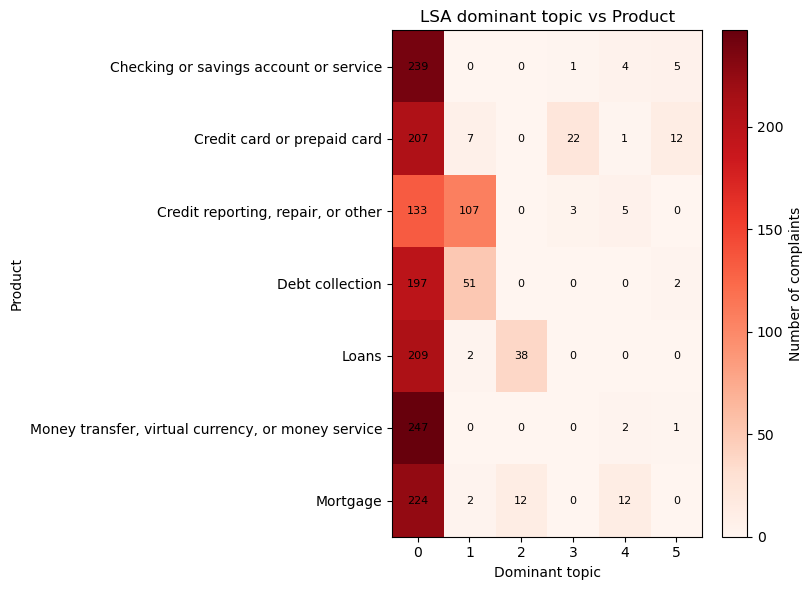

Saved plot to: /Users/davidlupau/Documents/Filen/_IU/6th semester/32. Project Data Analysis/complaint-topic-modeling/analysis_output/lda_dominant_topic_vs_product.png


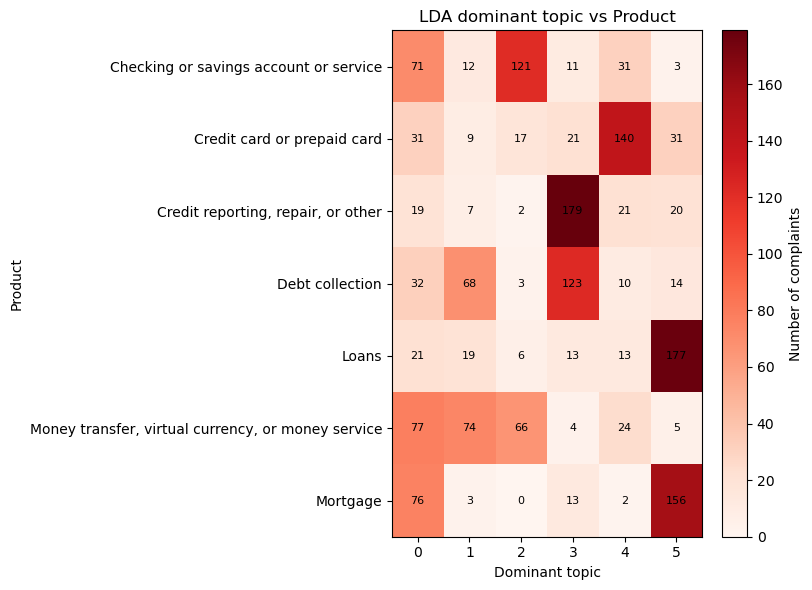

In [9]:
lsa_dominant_topics = assign_dominant_topic(lsa_model.transform(tfidf_matrix))
lda_dominant_topics = assign_dominant_topic(lda_model.transform(count_matrix))

plot_topic_vs_product(lsa_dominant_topics, df["Product"], "LSA dominant topic vs Product")
plot_topic_vs_product(lda_dominant_topics, df["Product"], "LDA dominant topic vs Product")

LDA's dominant-topic assignment aligns much more cleanly with Product than LSA's. Credit reporting concentrates strongly in Topic 3 (179/248), whose top words, report, debt, reporting, collection, bureau, dispute, agency, match the product category almost directly. Mortgage and Loans both concentrate in Topic 5, a lending-themed topic that sensibly spans both labels. Credit card concentrates in Topic 4. Notably, this alignment emerged with no access to Product during fitting — it is discovered structure, not fitted structure.

Money transfer, virtual currency, or money service spreads across Topics 0, 1, and 2 rather than concentrating in one — plausibly because this category itself bundles several distinct behaviors (bank transfers, crypto exchanges, general complaints). Topic 1 (Coinbase, phone, email, a crypto-exchange support topic) is well-represented here, which is a notable point of construct validity: an LDA topic found with no label information happens to align with the "virtual currency" part of this category's name.

LSA's alignment with Product is far weaker — nearly every product category is dominated by the same generic Topic 0, with only Credit reporting and Loans showing meaningful secondary concentration. This is consistent with, not separate from, the earlier finding that LSA explains only 9.2% of variance at k=6: with that little structure captured, most documents resemble each other along the dominant component regardless of their actual product. LDA's probabilistic, count-based approach produces noticeably more product-aligned topics on this corpus. To be clear, this comparison is a post-hoc validation check — Product was never used as input to either model, and it should be read as evidence about topic quality, not as a claim that either model was built to predict Product.